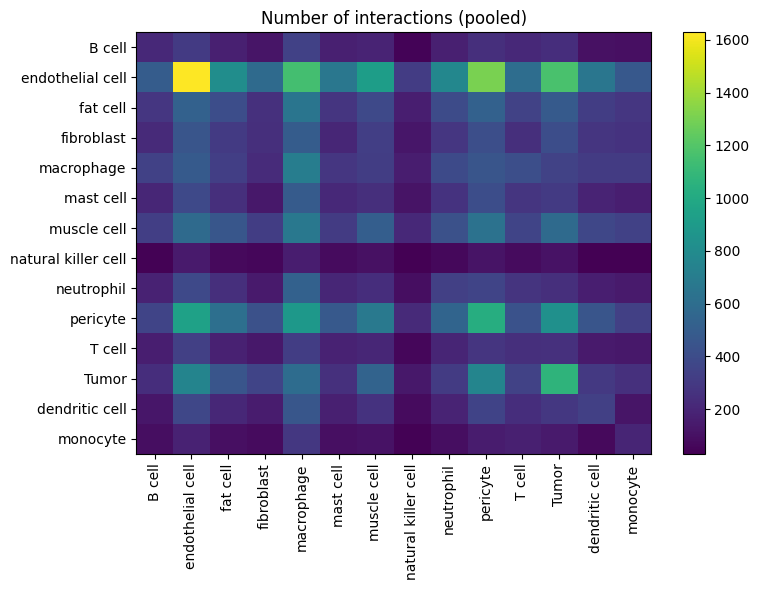

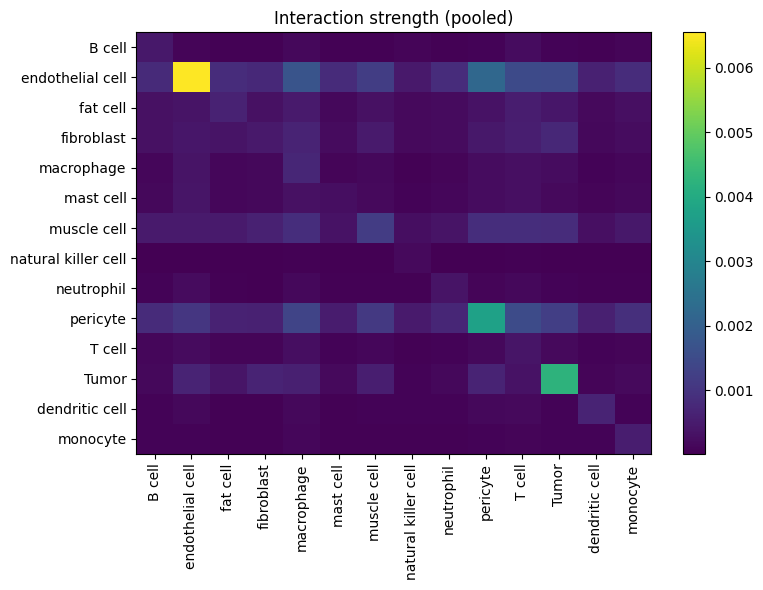

Top pathways (punch 10):
pathway
COLLAGEN    0.022723
CD99        0.012724
PECAM1      0.007779
LAMININ     0.007598
GALECTIN    0.004887
NOTCH       0.004773
THBS        0.003223
ADGRE       0.001974
GAP         0.001903
CXCL        0.001542
Name: prob, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("/Users/jiayifan/tansey_lab/cellchat/cellchat_export")  # 改成你的导出路径

# ===== 1) 读取 pooled 矩阵并画热图 =====
def read_mat_csv(p):
    df = pd.read_csv(p)
    df = df.rename(columns={'rownames':'celltype'})
    df = df.set_index('celltype')
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)
    return df

M_count  = read_mat_csv(root/"pooled_sum_count.csv")
M_weight = read_mat_csv(root/"pooled_mean_weight.csv")
celltypes = [x.strip() for x in (root/"celltypes.txt").read_text().splitlines() if x.strip()]

# 对齐顺序（如果 celltypes 与列完全一致，可以删掉这一步）
common = [ct for ct in celltypes if ct in M_count.index and ct in M_count.columns]
M_count  = M_count.loc[common, common]
M_weight = M_weight.loc[common, common]

# 简单热图
for name, M in [("Number of interactions (pooled)", M_count),
                ("Interaction strength (pooled)",  M_weight)]:
    plt.figure(figsize=(8,6))
    plt.imshow(M.values, interpolation='nearest', aspect='auto')
    plt.xticks(range(len(M.columns)), M.columns, rotation=90)
    plt.yticks(range(len(M.index)), M.index)
    plt.title(name)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# ===== 2) 读取 pathway 长表（单个或合并）并做 top pathways =====
# 示例：取某个 punch 的 pathways
p10 = root/"punch_10"/"pathway_long.csv"
if p10.exists():
    df_pw = pd.read_csv(p10)
    # 看最强的 10 个 pathway（按总 prob）
    top_pw = (df_pw.groupby("pathway")["prob"].sum()
              .sort_values(ascending=False).head(10))
    print("Top pathways (punch 10):")
    print(top_pw)

# ===== 3) 如果有全体 LRI 长表，画总体 Top-N LRI =====
all_lri = root/"ALL_punches_LRI_long.csv"
if all_lri.exists():
    lri = pd.read_csv(all_lri)
    top = (lri.groupby("interaction_name_2")["prob"]
           .mean().sort_values(ascending=False).head(30)).reset_index()
    plt.figure(figsize=(6,8))
    plt.barh(top["interaction_name_2"], top["prob"])
    plt.gca().invert_yaxis()
    plt.xlabel("Mean prob")
    plt.title("Top 30 LRIs across punches")
    plt.tight_layout()
    plt.show()


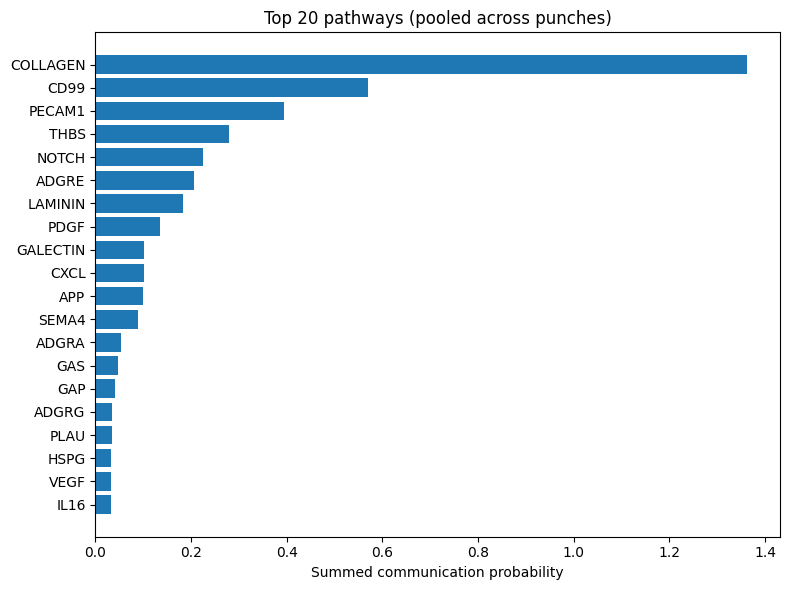

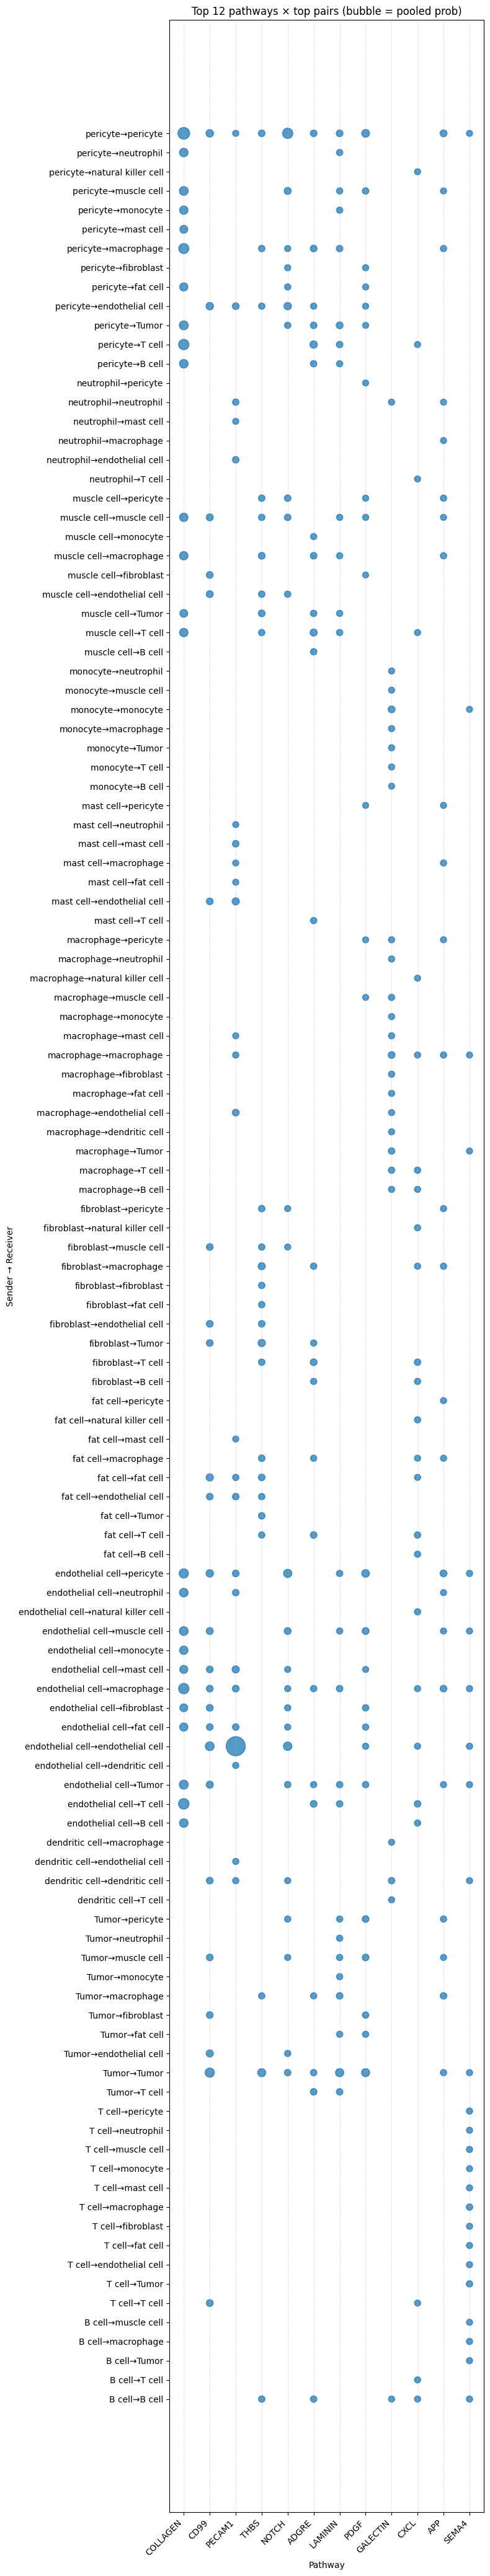

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 0) 路径与读取
# ================================
ROOT = root

# 收集所有 punch 的 pathway_long.csv
rows = []
for sub in ROOT.glob("punch_*/pathway_long.csv"):
    df = pd.read_csv(sub)
    if {"dataset","pathway","source","target","prob"}.issubset(df.columns):
        rows.append(df)
if not rows:
    raise FileNotFoundError("没有找到任何 punch_*/pathway_long.csv，请先按我给的 R 脚本导出。")

pw = pd.concat(rows, ignore_index=True)
# 清理
pw["pathway"] = pw["pathway"].astype(str)
pw["source"]  = pw["source"].astype(str)
pw["target"]  = pw["target"].astype(str)
pw["pair"]    = pw["source"] + "→" + pw["target"]
pw["prob"]    = pd.to_numeric(pw["prob"], errors="coerce").fillna(0.0)

# ================================
# 1) 图1：Top-N pathways（pooled across punches）
# ================================
TOP_N = 20  # 改你要的数量

agg_pw = (pw.groupby("pathway", as_index=False)["prob"]
            .sum()
            .sort_values("prob", ascending=False)
            .head(TOP_N))

plt.figure(figsize=(8, 6))
y = np.arange(len(agg_pw))
plt.barh(y, agg_pw["prob"].values)
plt.yticks(y, agg_pw["pathway"].tolist())
plt.gca().invert_yaxis()
plt.xlabel("Summed communication probability")
plt.title(f"Top {TOP_N} pathways (pooled across punches)")
plt.tight_layout()
plt.show()

# ================================
# 2) 图2：Top-K pathways × sender→receiver 的 bubble 图
#    - x: pathway（Top-K）
#    - y: sender→receiver
#    - size: pooled prob
# ================================
TOP_K = 12  # 取前 K 个 pathway 做展开，避免过于拥挤
top_k_paths = agg_pw["pathway"].head(TOP_K).tolist()

sub = pw[pw["pathway"].isin(top_k_paths)].copy()
# 对每个 (pathway, pair) 聚合（跨 punch）
grid = (sub.groupby(["pathway", "pair"], as_index=False)["prob"]
           .sum())

# 进一步只保留每个 pathway 的 Top-M pair（图更干净）
TOP_M_PER_PATH = 25
rows2 = []
for pth, g in grid.groupby("pathway"):
    g2 = g.sort_values("prob", ascending=False).head(TOP_M_PER_PATH)
    rows2.append(g2)
grid_top = pd.concat(rows2, ignore_index=True)

# 为 bubble 图准备离散坐标
x_paths = top_k_paths
y_pairs = sorted(grid_top["pair"].unique().tolist())  # 也可按总强度排序

xpos = grid_top["pathway"].map({p:i for i,p in enumerate(x_paths)}).values
ypos = grid_top["pair"].map({p:i for i,p in enumerate(y_pairs)}).values

# 点大小（适当缩放）
vals = grid_top["prob"].values
if len(vals) and vals.max() > 0:
    sizes = 50 + 450 * (vals / vals.max())
else:
    sizes = np.full_like(vals, 50.0)

plt.figure(figsize=(max(8, 0.6*len(x_paths)), max(6, 0.35*len(y_pairs))))
plt.scatter(xpos, ypos, s=sizes, alpha=0.75)
plt.xticks(range(len(x_paths)), x_paths, rotation=45, ha="right")
plt.yticks(range(len(y_pairs)), y_pairs)
plt.xlabel("Pathway")
plt.ylabel("Sender → Receiver")
plt.title(f"Top {TOP_K} pathways × top pairs (bubble = pooled prob)")
plt.grid(axis="x", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# ================================
# 3) （可选）单一路径的 sender→receiver 热图
# ================================
def plot_single_pathway_heatmap(pathway_name: str):
    dfp = (pw[pw["pathway"] == pathway_name]
             .groupby(["source","target"], as_index=False)["prob"].sum())
    if dfp.empty:
        print(f"[warn] pathway '{pathway_name}' 没有数据")
        return
    senders = sorted(dfp["source"].unique().tolist())
    targets = sorted(dfp["target"].unique().tolist())
    mat = pd.DataFrame(0.0, index=senders, columns=targets)
    for _, r in dfp.iterrows():
        mat.at[r["source"], r["target"]] = r["prob"]

    plt.figure(figsize=(0.5*len(targets)+3, 0.5*len(senders)+3))
    plt.imshow(mat.values, aspect="auto", interpolation="nearest")
    plt.xticks(range(len(targets)), targets, rotation=90)
    plt.yticks(range(len(senders)), senders)
    plt.title(f"{pathway_name} – pooled sender→receiver probability")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# 用法示例：
# plot_single_pathway_heatmap("CXCL")


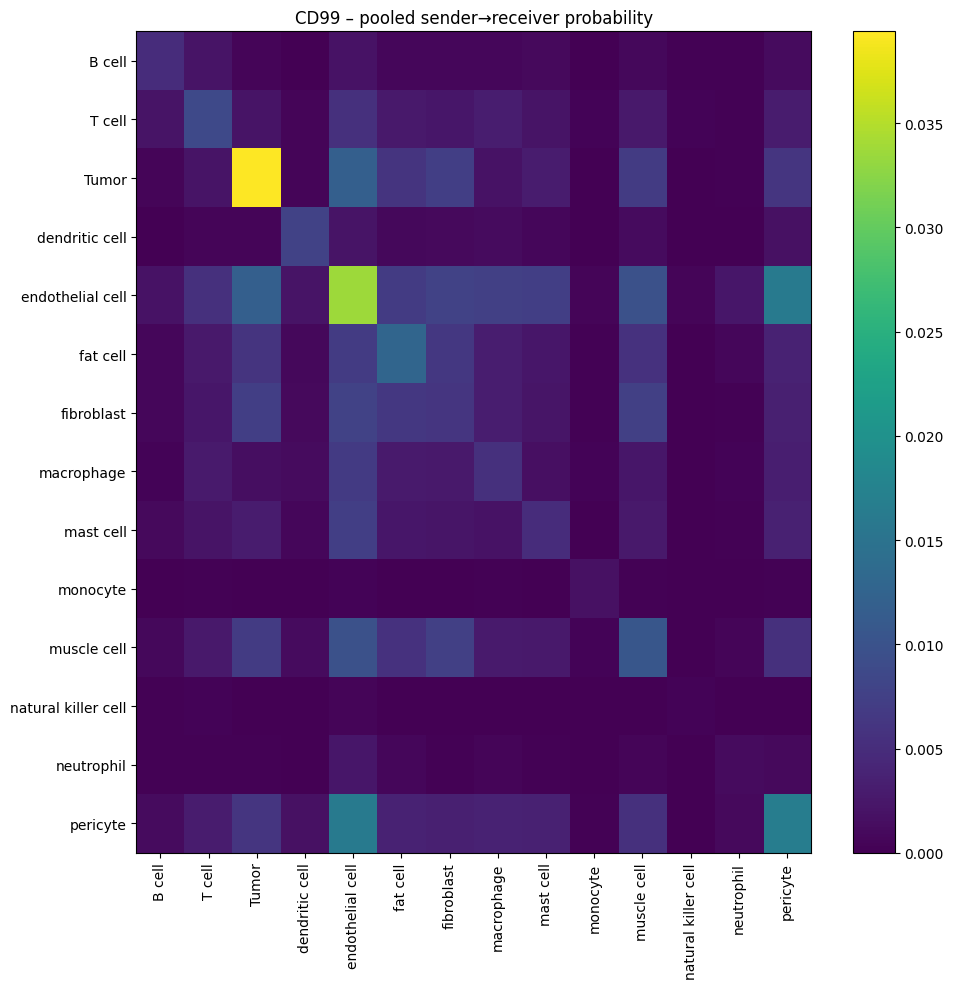

In [4]:
plot_single_pathway_heatmap("CD99")

In [5]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/Users/jiayifan/tansey_lab/cellchat/ALL_punches_LRI_long.csv')

# Filter for significant interactions (pval < 0.05)
df_sig = df[df['pval'] < 0.05].copy()

print(f"Original interactions: {len(df)}")
print(f"Significant interactions (pval < 0.05): {len(df_sig)}")

# Create a unique identifier for each (sender, receiver, LR) combination
df_sig['interaction_key'] = (df_sig['source'] + '_' + 
                             df_sig['target'] + '_' + 
                             df_sig['interaction_name'])

# Pivot to create the matrix: (sender,receiver,lr) x punches
# Using count as the value
interaction_matrix = df_sig.pivot_table(
    index='interaction_key',
    columns='dataset', 
    values='count',
    aggfunc='first',  # Since each combination should be unique per punch
    fill_value=0
)

print(f"\nMatrix shape: {interaction_matrix.shape}")
print(f"Rows (unique interactions): {interaction_matrix.shape[0]}")
print(f"Columns (punches): {interaction_matrix.shape[1]}")

# Add sum across punches as a new column
interaction_matrix['sum_across_punches'] = interaction_matrix.sum(axis=1)

# Sort by total count across punches (descending)
interaction_matrix = interaction_matrix.sort_values('sum_across_punches', ascending=False)

# Save the matrix
interaction_matrix.to_csv('interaction_matrix_pval05.csv')

print("\nTop 10 interactions by total count across punches:")
print(interaction_matrix['sum_across_punches'].head(10))

# Optional: Create a more detailed summary with interaction components
# Split the interaction key back into components for better readability
summary_df = pd.DataFrame({
    'interaction_key': interaction_matrix.index,
    'sum_count': interaction_matrix['sum_across_punches']
}).reset_index(drop=True)

# Split the key into components
summary_df[['source', 'target', 'lr_pair']] = summary_df['interaction_key'].str.split('_', n=2, expand=True)

# Reorder columns
summary_df = summary_df[['source', 'target', 'lr_pair', 'sum_count', 'interaction_key']]

# Save detailed summary
summary_df.to_csv('interaction_summary_pval05.csv', index=False)

print(f"\n✓ Saved interaction_matrix_pval05.csv")
print(f"✓ Saved interaction_summary_pval05.csv")

# Additional analysis: Statistics per punch
punch_stats = pd.DataFrame({
    'punch': interaction_matrix.columns[:-1],  # Exclude 'sum_across_punches' column
    'n_significant_interactions': (interaction_matrix.iloc[:, :-1] > 0).sum(),
    'total_count': interaction_matrix.iloc[:, :-1].sum()
})

print("\nStatistics per punch:")
print(punch_stats)

# Optional: Create a binary presence/absence matrix
interaction_binary = (interaction_matrix.iloc[:, :-1] > 0).astype(int)
interaction_binary['n_punches_present'] = interaction_binary.sum(axis=1)
interaction_binary.to_csv('interaction_binary_matrix_pval05.csv')

print(f"\n✓ Saved interaction_binary_matrix_pval05.csv (presence/absence)")

# If you want separate components in the matrix index
# Create a multi-index version
df_sig_multi = df_sig.copy()
interaction_matrix_multi = df_sig_multi.pivot_table(
    index=['source', 'target', 'interaction_name'],
    columns='dataset',
    values='count',
    aggfunc='first',
    fill_value=0
)

interaction_matrix_multi['sum_across_punches'] = interaction_matrix_multi.sum(axis=1)
interaction_matrix_multi = interaction_matrix_multi.sort_values('sum_across_punches', ascending=False)
interaction_matrix_multi.to_csv('interaction_matrix_multiindex_pval05.csv')

print(f"✓ Saved interaction_matrix_multiindex_pval05.csv (with multi-index)")

# Print some examples
print("\nExample of the matrix (first 5 rows, first 5 punches + sum):")
display_cols = list(interaction_matrix.columns[:5]) + ['sum_across_punches']
print(interaction_matrix[display_cols].head())

Original interactions: 108961
Significant interactions (pval < 0.05): 65822

Matrix shape: (9702, 65)
Rows (unique interactions): 9702
Columns (punches): 65

Top 10 interactions by total count across punches:
interaction_key
endothelial cell_endothelial cell_CDH5_CDH5        1628
endothelial cell_endothelial cell_PECAM1_PECAM1    1628
endothelial cell_endothelial cell_PTPRM_PTPRM      1625
endothelial cell_endothelial cell_JAG1_NOTCH1      1596
endothelial cell_endothelial cell_JAG1_NOTCH4      1596
endothelial cell_endothelial cell_CD46_JAG1        1433
endothelial cell_endothelial cell_VEGFC_VEGFR2     1422
endothelial cell_endothelial cell_DLL4_NOTCH4      1357
endothelial cell_endothelial cell_DLL4_NOTCH1      1357
endothelial cell_endothelial cell_VEGFC_VEGFR3     1346
Name: sum_across_punches, dtype: int64

✓ Saved interaction_matrix_pval05.csv
✓ Saved interaction_summary_pval05.csv

Statistics per punch:
        punch  n_significant_interactions  total_count
dataset             

In [6]:
interaction_matrix_multi

dataset                                                1   2   3   4   5   6  \
source           target              interaction_name                          
endothelial cell endothelial cell    CDH5_CDH5         8  51  27  53  32  27   
                                     PECAM1_PECAM1     8  51  27  53  32  27   
                                     PTPRM_PTPRM       8  51  27  53  32  27   
                                     JAG1_NOTCH1       0  51  27  53  32  27   
                                     JAG1_NOTCH4       0  51  27  53  32  27   
...                                                   ..  ..  ..  ..  ..  ..   
Tumor            natural killer cell MPZL1_MPZL1       0   0   0   0   0   0   
mast cell        dendritic cell      ADM_CALCRL        0   0   0   0   0   0   
dendritic cell   macrophage          CXCL5_CXCR1       0   0   0   0   0   0   
fat cell         mast cell           JAG1_NOTCH4       0   0   0   0   0   0   
neutrophil       fibroblast          SELE_CD44         0   0   0   0   0   0   

dataset                                                 7   8   9  10  ...  \
source           target              interaction_name                  ...   
endothelial cell endothelial cell    CDH5_CDH5         41  19  18  27  ...   
                                     PECAM1_PECAM1     41  19  18  27  ...   
                                     PTPRM_PTPRM       41  19  18  27  ...   
                                     JAG1_NOTCH1       41  19  18  27  ...   
                                     JAG1_NOTCH4       41  19  18  27  ...   
...                                                    ..  ..  ..  ..  ...   
Tumor            natural killer cell MPZL1_MPZL1        0   0   0   0  ...   
mast cell        dendritic cell      ADM_CALCRL         0   0   0   0  ...   
dendritic cell   macrophage          CXCL5_CXCR1        0   0   0   0  ...   
fat cell         mast cell           JAG1_NOTCH4        0   0   0   0  ...   
neutrophil       fibroblast          SELE_CD44          0   0   0   1  ...   

dataset                                                57  58  59  60  61  62  \
source           target              interaction_name                           
endothelial cell endothelial cell    CDH5_CDH5         16  14  26  28  20  27   
                                     PECAM1_PECAM1     16  14  26  28  20  27   
                                     PTPRM_PTPRM       16  14  26  28  20  27   
                                     JAG1_NOTCH1       16  14  26  28  20  27   
                                     JAG1_NOTCH4       16  14  26  28  20  27   
...                                                    ..  ..  ..  ..  ..  ..   
Tumor            natural killer cell MPZL1_MPZL1        0   0   0   0   0   0   
mast cell        dendritic cell      ADM_CALCRL         0   0   0   0   0   0   
dendritic cell   macrophage          CXCL5_CXCR1        0   0   0   0   0   0   
fat cell         mast cell           JAG1_NOTCH4        0   0   0   0   0   0   
neutrophil       fibroblast          SELE_CD44          0   0   0   0   0   0   

dataset                                                63  64  65  \
source           target              interaction_name               
endothelial cell endothelial cell    CDH5_CDH5         24  28  41   
                                     PECAM1_PECAM1     24  28  41   
                                     PTPRM_PTPRM       24  28  41   
                                     JAG1_NOTCH1       24  28  41   
                                     JAG1_NOTCH4       24  28  41   
...                                                    ..  ..  ..   
Tumor            natural killer cell MPZL1_MPZL1        0   0   0   
mast cell        dendritic cell      ADM_CALCRL         0   0   0   
dendritic cell   macrophage          CXCL5_CXCR1        0   0   0   
fat cell         mast cell           JAG1_NOTCH4        0   0   0   
neutrophil       fibroblast          SELE_CD44          0   0 

In [7]:
interaction_matrix

dataset,1,2,3,4,5,6,7,8,9,10,...,57,58,59,60,61,62,63,64,65,sum_across_punches
interaction_key,,,,,,,,,,,,,,,,,,,,,
endothelial cell_endothelial cell_CDH5_CDH5,8,51,27,53,32,27,41,19,18,27,...,16,14,26,28,20,27,24,28,41,1628
endothelial cell_endothelial cell_PECAM1_PECAM1,8,51,27,53,32,27,41,19,18,27,...,16,14,26,28,20,27,24,28,41,1628
endothelial cell_endothelial cell_PTPRM_PTPRM,8,51,27,53,32,27,41,19,18,27,...,16,14,26,28,20,27,24,28,41,1625
endothelial cell_endothelial cell_JAG1_NOTCH1,0,51,27,53,32,27,41,19,18,27,...,16,14,26,28,20,27,24,28,41,1596
endothelial cell_endothelial cell_JAG1_NOTCH4,0,51,27,53,32,27,41,19,18,27,...,16,14,26,28,20,27,24,28,41,1596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tumor_natural killer cell_MPZL1_MPZL1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
mast cell_dendritic cell_ADM_CALCRL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
dendritic cell_macrophage_CXCL5_CXCR1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
